In [ ]:
!pip install imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from imblearn.over_sampling import SMOTE


Data textfile does not contain headers, we have to add on the headers manually.

In [ ]:
# Define column names
column_names = ["age", "workclass", "fnlwgt", "education", "education-num",
                "marital-status", "occupation", "relationship", "race", "sex",
                "capital-gain", "capital-loss", "hours-per-week",
                "native-country", "outcome"]

# Read file and create Dataframe
df = pd.read_csv("adult.data", names=column_names)


In [ ]:
df["outcome"].value_counts()

,count
outcome,
<=50K,24720
>50K,7841


(array([24720.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  7841.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

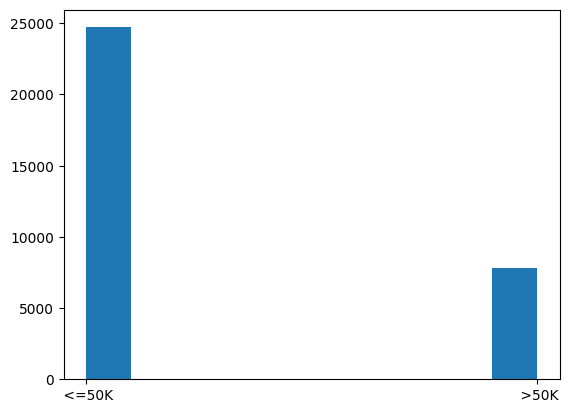

In [ ]:
plt.hist(df["outcome"])

Begin data exploration to look for missing values based on the UCI website.

In [ ]:
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,outcome
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  outcome         32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Seeking out missing values

print(df['workclass'].unique())
print(df['occupation'].unique())
print(df['native-country'].unique())

[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
[' United-States' ' Cuba' ' Jamaica' ' India' ' ?' ' Mexico' ' South'
 ' Puerto-Rico' ' Honduras' ' England' ' Canada' ' Germany' ' Iran'
 ' Philippines' ' Italy' ' Poland' ' Columbia' ' Cambodia' ' Thailand'
 ' Ecuador' ' Laos' ' Taiwan' ' Haiti' ' Portugal' ' Dominican-Republic'
 ' El-Salvador' ' France' ' Guatemala' ' China' ' Japan' ' Yugoslavia'
 ' Peru' ' Outlying-US(Guam-USVI-etc)' ' Scotland' ' Trinadad&Tobago'
 ' Greece' ' Nicaragua' ' Vietnam' ' Hong' ' Ireland' ' Hungary'
 ' Holand-Netherlands']


We can observe that " ?" exists as a value. As these are non-numerical values, we cannot replace them with mean or mode or median values. We will have to drop these missing data to ensure data integrity.

In [ ]:
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

In [ ]:
# Check if missing data are removed

print(df['workclass'].unique())
print(df['occupation'].unique())
print(df['native-country'].unique())

df.info()

[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' Self-emp-inc' ' Without-pay']
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Transport-moving' ' Farming-fishing'
 ' Machine-op-inspct' ' Tech-support' ' Craft-repair' ' Protective-serv'
 ' Armed-Forces' ' Priv-house-serv']
[' United-States' ' Cuba' ' Jamaica' ' India' ' Mexico' ' Puerto-Rico'
 ' Honduras' ' England' ' Canada' ' Germany' ' Iran' ' Philippines'
 ' Poland' ' Columbia' ' Cambodia' ' Thailand' ' Ecuador' ' Laos'
 ' Taiwan' ' Haiti' ' Portugal' ' Dominican-Republic' ' El-Salvador'
 ' France' ' Guatemala' ' Italy' ' China' ' South' ' Japan' ' Yugoslavia'
 ' Peru' ' Outlying-US(Guam-USVI-etc)' ' Scotland' ' Trinadad&Tobago'
 ' Greece' ' Nicaragua' ' Vietnam' ' Hong' ' Ireland' ' Hungary'
 ' Holand-Netherlands']
<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Co

Now that missing values are removed. We will continue data cleanup by finding duplicated values and remove them.

In [ ]:
count_duplicates = df.duplicated().sum()
print(count_duplicates)

23


In [ ]:
df_cleaned = df.drop_duplicates()
check_duplicates = df_cleaned.duplicated().sum()
print(check_duplicates)

0


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education-num   30139 non-null  int64 
 5   marital-status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital-gain    30139 non-null  int64 
 11  capital-loss    30139 non-null  int64 
 12  hours-per-week  30139 non-null  int64 
 13  native-country  30139 non-null  object
 14  outcome         30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Detect outliers and remove?

After data is cleaned, we will move onto encoding categorical values into numerical ones so that the model will be able to understand the values.

First we check if 'education' and 'education-num' is related and already encoded.

In [ ]:
print(df_cleaned['education'].unique())
print(df_cleaned['education-num'].unique())

[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' 7th-8th' ' Doctorate' ' Assoc-voc' ' Prof-school'
 ' 5th-6th' ' 10th' ' Preschool' ' 12th' ' 1st-4th']
[13  9  7 14  5 10 12  4 16 11 15  3  6  1  8  2]


There are 16 different types of values in both 'education' and 'education-num'. To prove that they are already encoded, lets see if the data match are consistent.

In [ ]:
filtered_df = df_cleaned.loc[(df_cleaned['education'] == ' Bachelors')]
print(filtered_df)

filtered_df_2 = df_cleaned.loc[(df_cleaned['education-num'] == 4)]
print(filtered_df_2)

       age          workclass  fnlwgt   education  education-num  \
0       39          State-gov   77516   Bachelors             13   
1       50   Self-emp-not-inc   83311   Bachelors             13   
4       28            Private  338409   Bachelors             13   
9       42            Private  159449   Bachelors             13   
11      30          State-gov  141297   Bachelors             13   
...    ...                ...     ...         ...            ...   
32507   50            Private  302372   Bachelors             13   
32511   25          Local-gov  514716   Bachelors             13   
32533   54            Private  337992   Bachelors             13   
32536   34            Private  160216   Bachelors             13   
32538   38            Private  139180   Bachelors             13   

            marital-status        occupation    relationship  \
0            Never-married      Adm-clerical   Not-in-family   
1       Married-civ-spouse   Exec-managerial         Hu

This has proven that "education-num" is the encoded version of "education". We can go ahead and remove the "education" column as it is no longer needed. Before removing the column we will display all the "education" unique values and its encoded form for future human reference if needed. This is solely semantical.

In [ ]:
for unique_value, sub_df in df_cleaned.groupby('education'):
    print(f"Education: {unique_value}")
    print(f"Encoded: {sub_df['education-num'].unique()}")

Education:  10th
Encoded: [6]
Education:  11th
Encoded: [7]
Education:  12th
Encoded: [8]
Education:  1st-4th
Encoded: [2]
Education:  5th-6th
Encoded: [3]
Education:  7th-8th
Encoded: [4]
Education:  9th
Encoded: [5]
Education:  Assoc-acdm
Encoded: [12]
Education:  Assoc-voc
Encoded: [11]
Education:  Bachelors
Encoded: [13]
Education:  Doctorate
Encoded: [16]
Education:  HS-grad
Encoded: [9]
Education:  Masters
Encoded: [14]
Education:  Preschool
Encoded: [1]
Education:  Prof-school
Encoded: [15]
Education:  Some-college
Encoded: [10]


We can observe that "education-num" is ordinally encoded. Ranking them based on heirachy where 1 is the lowest and 16 is the highest form of education in this given context.

In [ ]:
df_transform_1 = df_cleaned.drop(columns=['education'])
df_transform_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education-num   30139 non-null  int64 
 4   marital-status  30139 non-null  object
 5   occupation      30139 non-null  object
 6   relationship    30139 non-null  object
 7   race            30139 non-null  object
 8   sex             30139 non-null  object
 9   capital-gain    30139 non-null  int64 
 10  capital-loss    30139 non-null  int64 
 11  hours-per-week  30139 non-null  int64 
 12  native-country  30139 non-null  object
 13  outcome         30139 non-null  object
dtypes: int64(6), object(8)
memory usage: 3.4+ MB


In [ ]:
df_transform_1['outcome'].unique()

array([' <=50K', ' >50K'], dtype=object)

We can apply one hot encoding to all categorical columns.

(array([22633.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  7506.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

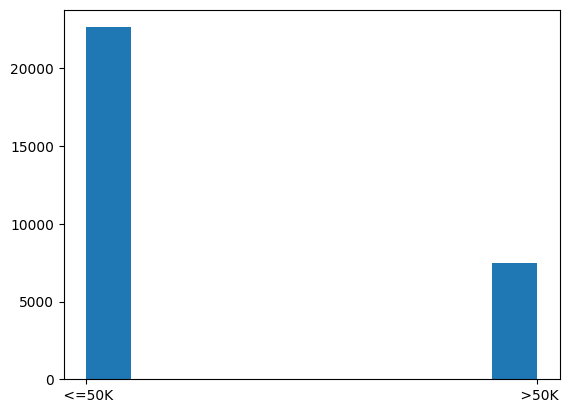

In [ ]:
# imbalance dataset
plt.hist(df_transform_1["outcome"])

First we split the dataset into training (80%) and test (20%) sets.

In [ ]:
from sklearn.model_selection import train_test_split

# converts target column into binary
df_transform_1['outcome'] = np.where(df_transform_1['outcome'].str.strip() == '>50K', 1, 0)


X = df_transform_1.drop(columns=['outcome']) # features
y = df_transform_1['outcome'] # target


# First split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=30,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 24111
Test size: 6028


In [ ]:
y.value_counts()

,count
outcome,
0,22633
1,7506


Data Splitting / Analyse Class Probability

In [ ]:
# get numerical columns and categorical columns for train  data to prepare data for preprocessing

train_num = X_train.select_dtypes(include="int").copy()
train_cat = X_train.select_dtypes(include="object").copy()


In [ ]:
# create pipelines to process numerical and categorical features of training data.
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include="number")),
    ("cat", cat_pipeline, make_column_selector(dtype_include="object"))
], remainder='drop')

#**MLP**

Test Accuracy: 0.8195089581950896

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      4527
           1       0.62      0.73      0.67      1501

    accuracy                           0.82      6028
   macro avg       0.76      0.79      0.77      6028
weighted avg       0.83      0.82      0.82      6028



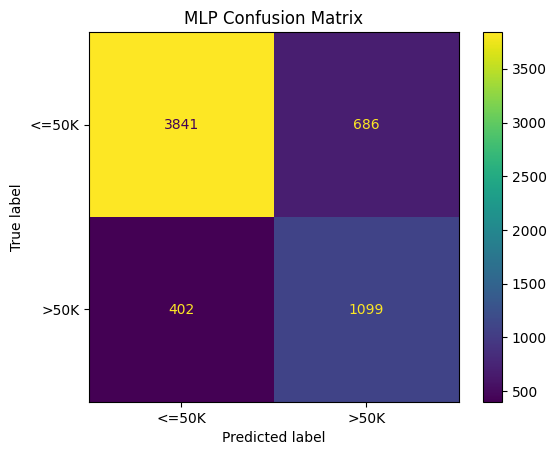

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("smote", SMOTE(random_state=42)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=30
    ))
])

# Train
mlp_pipeline.fit(X_train, y_train)

# Predict
y_pred = mlp_pipeline.predict(X_test)

# Metrics
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot()
plt.title("MLP Confusion Matrix")
plt.show()


MLP Hyperparam tuning to find best.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__hidden_layer_sizes": [(64,32), (128,64), (128,64,32)],
    "classifier__alpha": [0.0001, 0.0005, 0.001],
    "classifier__learning_rate_init": [0.001, 0.005]
}

grid = GridSearchCV(mlp_pipeline, param_grid, cv=3, scoring="accuracy", n_jobs=-1)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


Best parameters: {'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__learning_rate_init': 0.001}
Best CV accuracy: 0.8128654970760234


Test Accuracy (Best MLP): 0.807398805573988

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86      4527
           1       0.58      0.79      0.67      1501

    accuracy                           0.81      6028
   macro avg       0.75      0.80      0.77      6028
weighted avg       0.84      0.81      0.82      6028



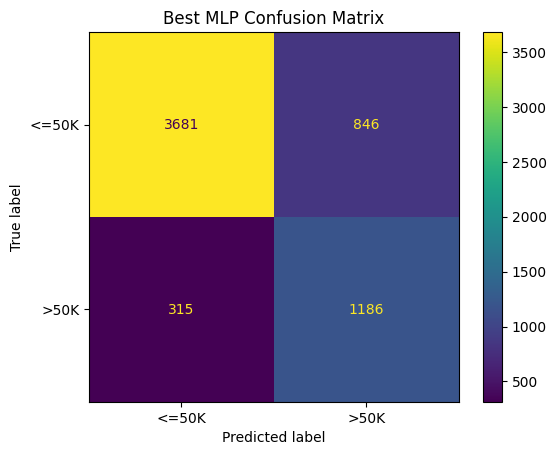

In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Test Accuracy (Best MLP):", accuracy_score(y_test, y_pred_best))

print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot()
plt.title("Best MLP Confusion Matrix")
plt.show()
